In [ ]:
!python -m spacy download en_core_web_sm

In [50]:
def get_sentence_index(sentences, start, end):
    sentence_index = 0
    for sentence_idx, (sent_start, sent_end) in enumerate(sentences):
        if sent_start <= start and sent_end >= end:
            sentence_index = sentence_idx
    return sentence_index
    
def split_text_into_sentenes(text):
    tokenizer = nltk.data.load('tokenizers/punkt/english.pickle')
    sentences = list(tokenizer.span_tokenize(text))
    return sentences

def generate_all_event_pairs(events):
    pairs = []
    for i in range(len(events) - 1):
        for j in range(i+1, len(events)):
            pairs.append((events[i], events[j]))
    return pairs

import spacy
nlp = spacy.load("en_core_web_sm")
def generate_event_pairs(text, events):
    pairs = []
    # get event pars that appear in the same sentence
    sentences = split_text_into_sentenes(text)
    event_sentence_indexes = []
    for event_idx, event in enumerate(events):
        start, end, event_text = event
        sentence_index = get_sentence_index(sentences, start, end)
        event_sentence_indexes.append((sentence_index, event_idx))

    for sentence_idx in range(len(sentences)):
        events_from_this_sentence = list(map(lambda event_sent: events[event_sent[1]], filter(lambda event_sent: event_sent[0] == sentence_idx, event_sentence_indexes)))
        pairs += generate_all_event_pairs(events_from_this_sentence)

    # between sentence pairs
    # split events into sentences
    events_in_sentences = [[] for _ in sentences]
    for event_idx, event in enumerate(events):
        start, end, event_text = event
        sentence_index = get_sentence_index(sentences, start, end)
        events_in_sentences[sentence_index].append((event, event_idx))
    # sort event in sentences
    for s in events_in_sentences:
        s.sort(key=lambda event: event[0][0])
    # add relations between main events in subsequent sentences
    for i in range(len(events_in_sentences)-1):
        if len(events_in_sentences[i]) == 0 or len(events_in_sentences[i+1]) == 0:
            continue
        pairs.append((events_in_sentences[i][0][0], events_in_sentences[i + 1][0][0]))
        if len(events_in_sentences[i]) > 1:
            pairs.append((events_in_sentences[i][-1][0], events_in_sentences[i+1][0][0]))
        if len(events_in_sentences[i+1]) > 1:
            pairs.append((events_in_sentences[i][0][0], events_in_sentences[i + 1][-1][0]))
        if len(events_in_sentences[i]) > 1 and len(events_in_sentences[i+1]) > 1:
            pairs.append((events_in_sentences[i][-1][0], events_in_sentences[i + 1][-1][0]))

    # Add relations between events with correference
    events_by_main_words = {}
    for event in events:
        head_word = ""
        for token in nlp(event[2]):
            if token.dep_ == "ROOT":
                head_word = token.text
        if head_word not in events_by_main_words:
            events_by_main_words[head_word] = []
        events_by_main_words[head_word].append(event)
    for hw in events_by_main_words:
        evs = events_by_main_words[hw]
        for i in range(len(evs)-1):
            for j in range(i+1,len(evs)):
                pairs.append((evs[i], evs[j]))
    return pairs

In [51]:
dataframe = dataset_test_ub.df
documents = set(dataframe["document_id"])
dataset = []
for doc in documents:
    relations = dataframe[dataframe["document_id"] == doc]
    text = relations["text"].iloc[0]
    graph = []
    for row in relations.iloc:
        graph.append(((row["event1_start"], row["event1_end"], row["event1_text"]), row["class"], (row["event2_start"], row["event2_end"], row["event2_text"])))
    dataset.append({"text": text, "graph": graph})
    

In [52]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [53]:
tp = 0
fp = 0
tn = 0
fn = 0
for doc in range(len(dataset)):
    events = set([r[0] for r in dataset[doc]["graph"]] + [r[2] for r in dataset[doc]["graph"]])
    # print(events)
    event_pairs = generate_event_pairs(dataset[doc]["text"], list(events))
    # print(event_pairs)
    graph = dataset[doc]["graph"]
    
    for r in graph:
        # is it detected
        detected = False
        for p in event_pairs:
            if (p[0] == r[0] and p[1] == r[2]) or (p[0] == r[2] and p[1] == r[0]):
                detected = True
        if detected:
            tp += 1
        else:
            fn += 1
    for p in event_pairs:
        # is it detected
        detected = False
        for r in graph:
            if (p[0] == r[0] and p[1] == r[2]) or (p[0] == r[2] and p[1] == r[0]):
                detected = True
        if not detected:
            fp += 1


p = tp/(tp+fp)
r = tp/(tp+fn)
f1 = (2*p*r)/(p+r)
print(p,r,f1)

0.23572194150972287 0.7859938733832539 0.36267619458950096


# Prepare workspace

In [3]:
ls

'End-to-end ablation study.ipynb'      NoRelationDetection.ipynb
'Error analysis.ipynb'                'Pipeline test.ipynb'
'Event extraction evaluation.ipynb'   'convert dataset to bionlp.ipynb'
'Event extraction using Flair.ipynb'   glm_testiranje.ipynb
'LLM event extraction.ipynb'           gpt_model_testing.ipynb
'Manual end-to-end evaluation.ipynb'  'train event extraction.ipynb'


In [4]:
cd ..

/workspace/llm-graph-construction


/opt/conda/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
!pip install gensim

In [6]:
!pip install cryptpandas

In [7]:
from training.train_and_evaluate_relation_extraction import load_stored_dataset_combination_graph
from custom_datasets.dataframe_dataset import DFDataset

/workspace/llm-graph-construction


/workspace/llm-graph-construction/graph_building/llm/OpenChat.py:10: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  ollama = Ollama(base_url='http://localhost:11434',


# Loading the dataset

In [8]:
dataset_train, dataset_val, dataset_test_ub = load_stored_dataset_combination_graph(balanced=False, dataset="i2b2")
number_of_relations = 3

In [16]:
for i in range(len(dataset_train.generated)):
    e1 = dataset_train.generated[i]["text"][dataset_train.generated[i]["event1_start"]:dataset_train.generated[i]["event1_end"]]
    print(e1)
    print(dataset_train.df.iloc[i]["event1_text"])
    break

his suprapubic catheter
the catheter


In [26]:
import torch
dataset_train.generated[0]

Data(x=[142, 768], edge_index=[2, 960], edge_attr=[960, 775], y=[1], edge_type=[960], event1_index=[1], event2_index=[1], text_relations=[845], text='prior to admission he complained discomfort over a suprapubic catheter area .
The patient had missed his usual monthly change of <e1>his suprapubic catheter</e1> and felt discomfort and noticed some blood at the site of <e2>the catheter</e2> .
The patient was brought to the Emergency Room one', event1_start=133, event1_end=156, event2_start=224, event2_end=236)

In [18]:
for i in range(len(dataset_train.generated)):
    e1 = dataset_train.generated[i]["text"][dataset_train.generated[i]["event1_start"]:dataset_train.generated[i]["event1_end"]]
    print(e1)

his suprapubic catheter
presented
sensitive
readmitted
a temperature
a hematocrit
Her vital signs
sodium acetate
her potassium
A bronchoscopy
ADMISSION
the floor
A orogastric tube
pulmonary function studies
transferred
an ovarian mass
a right craniotomy
transplant
NPO
Chest soreness
clubbing
shock liver
bowel sounds
an ID reaction
a new rub
the CSF fluid
read
delivery
bradycardia
an intramedullary rodding of the femur
a general diet
extrinsic compression of the high trachea
prolonged wean
set to a VVI mode
Weight
the vascular surgery
fall
could not walk
tubefeed
her lisinopril
severe coagulopathy
many cultures
diastolic BP
connection
Quincy Medical Center
admitted
the procedure
discharge
Head CT
numerous clots
hematuria
worsening mitral stenosis
subj / obj fevers
tells
a desire
metastatic RCC
transferred
transfer
infectious diseases
examination
discharged
transfused
Tranferred
the ICU
a heart murmur
CXR
ADMISSION
the assessment
His initial blood gases
arrival
the tumor
PT consult
her p

In [19]:
for i in range(len(dataset_train.generated)):
    print(dataset_train.df.iloc[i]["event1_text"])

the catheter
severe retrosternal chest pain
Ceftazidime
new abscess in her left lower calf
a temperature
denied
post transfusion HCT
a spontaneous vaginal delivery
Her vital signs
sodium acetate
her potassium
a sputum sample
the catheterization
hypertension
stable condition
A orogastric tube
pulmonary function studies
constipation
a 14 x 14 x 10 cm pelvic mass
a right craniotomy
transplant
NPO
admission
Chest soreness
clubbing
shock liver
This bone marrow transplant
flatus
tubefeed
an ID reaction
healed
a new rub
His initial CBC
the CSF fluid
a facet hypertrophy
transferred
bradycardia
penicillin
Spine straight
open reduction
voiding on her own
extrinsic compression of the high trachea
prolonged wean
sensed appropriately
Weight
surgery
CT of the neck
the pain
tubefeed
her lisinopril
swan numbers
FFP
all negative
nitroprusside gtt
diuresis
connection
the Emergency Department
Owaleharbo Tanaminer Hospital
did well
Discharge INR
ABG
the hospital course
Mental status improved
infection
hem

In [5]:
# Analyzing the data

In [10]:
from custom_datasets.combining_data import window_row_entity_bert
count_missed = 0
count_all = 0
for i, row in dataset_train.df.iterrows():
    count_all += 1
    windowed_row = window_row_entity_bert(row, normalize_event_order=False)
    if windowed_row is None:
        count_missed += 1
    # print(windowed_row)
print(count_missed/count_all)

0.13793795803634173


# Set event extraction

In [6]:
!pip install -q flair==0.12.2

In [ ]:
from flair.embeddings import TransformerWordEmbeddings
from flair.models import SequenceTagger
from flair.trainers import ModelTrainer
from flair.data import Sentence

In [ ]:
def get_predictions(tagged_sentence, original_text):
    predicted_events = []
    curent_event = [0,0]
    in_event = False
    offset = 0
    for word in tagged_sentence:
        offset = original_text.find(word.text, offset)
        if word.tag == "B":
            if in_event:
                # complete curent event
                predicted_events.append((curent_event[0], curent_event[1], original_text[curent_event[0]: curent_event[1]]))
                current_event = [offset, offset]
                in_event = False
            in_event = True
            curent_event[0] = offset
            curent_event[1] = offset + len(word.text)
        elif word.tag == "I" and in_event == True:
            curent_event[1] = offset + len(word.text)
        elif word.tag == "I" and in_event == False:
            # ignore events without a beginning
            # in_event = True
            # curent_event[0] = offset
            # curent_event[1] = offset + len(word.text)
            pass
        elif word.tag == "X" and in_event == True:
            # complete curent event
            predicted_events.append((curent_event[0], curent_event[1], original_text[curent_event[0]: curent_event[1]]))
            curent_event = [offset, offset]
            in_event = False
        
        
        offset += len(word.text)
    return predicted_events

In [10]:
test_name = "i2b2"
model = SequenceTagger.load('resources/taggers/sota-ner-flert-'+test_name+'2/final-model.pt')
def extract_events(text):
    sentence = Sentence(text)
    # predict tags and print
    model.predict(sentence)
    predictions = get_predictions(sentence, text)
    return predictions

Downloading:   0%|          | 0.00/616 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.09G [00:00<?, ?B/s]

2024-12-12 09:24:06,207 SequenceTagger predicts: Dictionary with 3 tags: X, I, B


# Running basic pipeline

In [7]:
from pipeline.pipeline import *

In [8]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz

  Using cached https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz (14.8 MB)
  Preparing metadata (setup.py) ... one
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install transformers==4.20.1

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 131.6 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.27.3
    Uninstalling transformers-4.27.3:
      Successfully uninstalled transformers-4.27.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.1.1 requires transformers==4.43.4, but you have transformers 4.20.1 which is incompatible.
optimum 1.23.3 requires transformers>=4.29, but you have transformers 4.

In [6]:
!pip install transformers==4.37.2

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [15]:
!pip install sentence-transformers==2.7.0

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.2.1
    Uninstalling sentence-transformers-3.2.1:
      Successfully uninstalled sentence-transformers-3.2.1


In [4]:
relation_types = ["BEFORE", "AFTER", "OVERLAP"]
graph = analyze_document("He came to the hospital for a checkup on a mole that appeared two weeks ago.", 0)

Events:
[(11, 23, 'the hospital'), (28, 37, 'a checkup'), (41, 47, 'a mole')]
Pairs (3):
[((11, 23, 'the hospital'), (28, 37, 'a checkup')), ((11, 23, 'the hospital'), (41, 47, 'a mole')), ((28, 37, 'a checkup'), (41, 47, 'a mole'))]


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max 

Accuracy: 0.5
Number of relations: 1.0

 ... executing workers ...

Graph 0 generated
Graph 1 generated
Graph 2 generated
Generated 3 examples


# Debugging

In [ ]:
text = "He came to the hospital for a checkup on a mole that appeared two weeks ago."
patient_id = 0
# debugging analyze_document
events = extract_events(text)
print("Events:")
print(events)
event_pairs = generate_event_pairs(text, events)
dataframe = construct_basic_dataframe(text, event_pairs, 0)
dataset = construct_dataset_with_graphs(text, dataframe, patient_id)
relations = predict_temporal_relations(dataset)

In [ ]:
configuration = get_configuration_for_building_local_graph()
local_kg = construct_graph_from_text_only(dataframe, configuration, dataset_type="train")
dataset = create_knowledge_graph_dataset(dataframe, generate_fast_combination_graph, configuration=configuration,
                                local_graph=local_kg, cache_only=False, insert_time_nodes=True,
                                graph_post_processing=add_stored_data_to_kg, patient_id=patient_id, relation_types=relation_types)
dataset.pregenerate_and_filter()
print(len(dataset))

In [ ]:
print(len(dataset))
loader = DataLoader(dataset, batch_size=16)
for batch in loader:
    labels = batch.y
    result = model(data=batch, labels=labels)
    print(results)
    predictions = np.argmax(result["predictions"].cpu().detach().numpy(), axis=1)
    print(predictions)

# End debugging

# Graph visualization

In [9]:
import networkx as nx
G = nx.Graph()
events = ["test1", "test2"]
edges = {("test1", "test2"): "before"}
G.add_nodes_from(events)
G.add_edges_from(edges.keys())


In [10]:
events = set()
edges = {}
for triplet in graph:
    events.add(triplet[0])
    events.add(triplet[2])
    edges[(triplet[0], triplet[2])] = triplet[1]
events = list(events)
G = nx.Graph()
G.add_nodes_from(events)
G.add_edges_from(edges.keys())


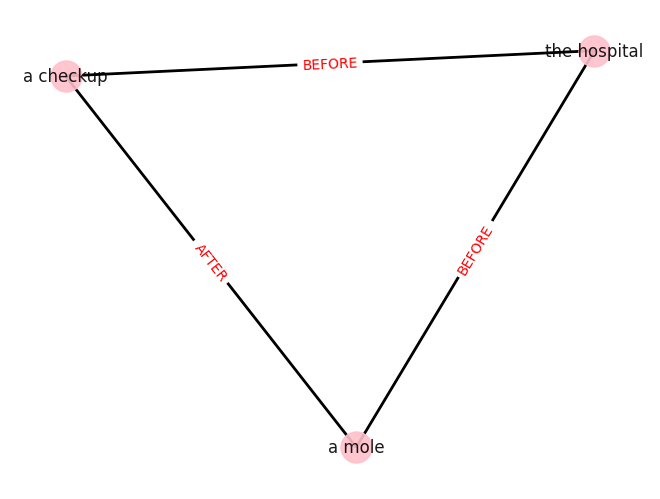

In [11]:
import matplotlib.pyplot as plt
plt.figure()
pos = nx.spring_layout(G)
nx.draw(
    G, pos, edge_color='black', width=1, linewidths=1,
    node_size=500, node_color='pink', alpha=0.9,
    labels={node: node for node in G.nodes()}
)
nx.draw_networkx_edges(
    G,
    pos,
    node_size=500,
    arrowstyle="->",
    arrowsize=10,
    width=2,
)
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edges,
    font_color='red'
)
plt.axis('off')
plt.show()

# Preparing data from the dataset

In [10]:
dataframe = dataset_test_ub.df

In [11]:
documents = set(dataframe["document_id"])
dataset = []
for doc in documents:
    relations = dataframe[dataframe["document_id"] == doc]
    text = relations["text"].iloc[0]
    graph = []
    for row in relations.iloc:
        graph.append(((row["event1_start"], row["event1_end"], row["event1_text"]), row["class"], (row["event2_start"], row["event2_end"], row["event2_text"])))
    dataset.append({"text": text, "graph": graph})
    

In [12]:
patient_ind = 1
example = dataset[patient_ind]

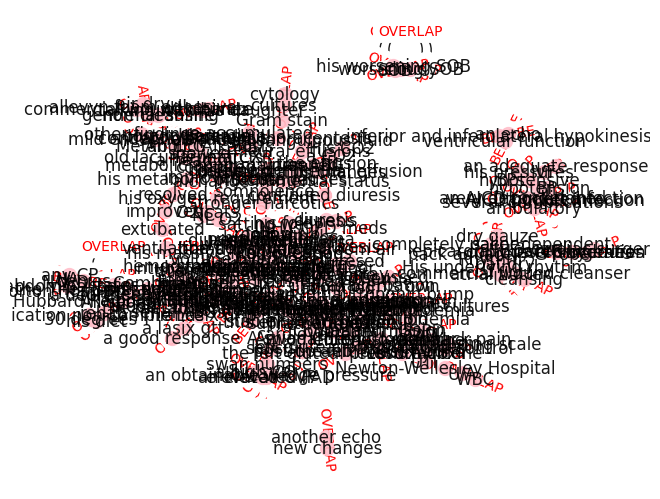

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
def visualize_graph(grpah):
    events = set()
    edges = {}
    for triplet in graph:
        events.add(triplet[0][2])
        events.add(triplet[2][2])
        edges[(triplet[0][2], triplet[2][2])] = triplet[1]
    events = list(events)
    G = nx.Graph()
    G.add_nodes_from(events)
    G.add_edges_from(edges.keys())

    plt.figure()
    pos = nx.spring_layout(G)
    nx.draw(
        G, pos, edge_color='black', width=1, linewidths=1,
        node_size=100, node_color='pink', alpha=0.9,
        labels={node: node for node in G.nodes()}
    )
    # nx.draw_networkx_edges(
    #     G,
    #     pos,
    #     node_size=100,
    #     arrowstyle="->",
    #     arrowsize=10,
    #     width=2,
    # )
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edges,
        font_color='red'
    )
    plt.axis('off')
    plt.show()
    
visualize_graph(example["graph"])

# Automatic graph comparison

In [22]:
def overlap(event1, event2):
    start1, end1, text1 = event1
    start2, end2, text2 = event2
    if start1 >= start2 and start1 <= end2:
        # print(event1, event2)
        return True
    if end1 >= start2 and end1 <= end2:
        # print(event1, event2)
        return True
    if start2 >= start1 and start2 <= end1:
        # print(event1, event2)
        return True
    return False

def most_simmilar_event(event_list, event_target):
    # min_difference = -1
    # best_match = None
    for e in event_list:
        if overlap(e, event_target):
            return e
        # dif = -1
        # if e in event_target:
        #     dif = len(event_target) - len(e)
        # if event_target in e:
        #     dif = len(e) - len(event_target)
        # if dif >= 0 and (min_difference < 0 or min_difference > dif):
        #     min_difference = dif
        #     best_match = e
    return None

def find_relation(graph, event1, event2, expected_relation):
    for ind, r in enumerate(graph):
        if r[0] == event1 and r[2] == event2 and r[1] == expected_relation:
            return ind, r
    for ind, r in enumerate(graph):
        if r[0] == event1 and r[2] == event2:
            return ind, r
    return -1, None

# compare_graphs(truth, prediction)
def compare_graphs(graph1, graph2):
    event_map = {}
    events1 = list(set([r[0] for r in graph1]+[r[2] for r in graph1]))
    events2 = list(set([r[0] for r in graph2]+[r[2] for r in graph2]))
    for e in events1:
        event_map[e] = most_simmilar_event(events2, e)
    #print(event_map)
    
    matching_relation = [False for _ in range(len(graph2))]
    
    correct = 0
    incorrect = 0
    missing = 0
    too_much = 0
    for relation in graph1:
        ind2, relation2 = find_relation(graph2, event_map[relation[0]], event_map[relation[2]], relation[1])
        if relation2 is None:
            missing += 1
        else:
            matching_relation[ind2] = True
            if relation[1] == relation2[1]:
                correct += 1
            else:
                incorrect += 1
    too_much = len(matching_relation) - sum(matching_relation)
    #print(correct, incorrect, missing, too_much)
    return correct, incorrect, missing, too_much

In [23]:
compare_graphs(example["graph"], example["graph"])

(107, 0, 0, 0)

## Example on predicted graph

In [ ]:
relation_types = ["BEFORE", "AFTER", "OVERLAP"]
graph_predicted = analyze_document(example["text"], patient_ind)

## Try to align generated graph to the ground truth graph

In [24]:
def get_event_pairs_of_interest(example):
    graph = example["graph"]
    event_pairs = []
    for g in graph:
        event_pairs.append((g[0], g[2]))
    return list(event_pairs)

In [25]:
from custom_datasets.combining_data import window_row_entity_bert
def window_text(graph):
    graph = window_row_entity_bert(graph, normalize_event_order=False)
    if graph is None:
        return None
    return graph

In [26]:
def predict_temporal_relations(dataset):
    human_readable_predictions = []
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    model = torch.load("multimodal-model.pt", map_location=device)

    loader = DataLoader(dataset, batch_size=16)
    for batch in loader:
        batch.to(device)
        labels = batch.y
        result = model(data=batch, labels=labels)
        predictions = np.argmax(result["predictions"].cpu().detach().numpy(), axis=1)
        for i in range(len(batch["text"])):
            event1 = batch["event1_oroginal_position"][i]
            event2 = batch["event2_oroginal_position"][i]
            human_readable_predictions.append((event1, relation_types[predictions[i]], event2))
    return human_readable_predictions

In [27]:
def analyze_document(text, patient_id, event_pairs_of_interest=None):
    events = extract_events(text)
    # print("Events:")
    # print(events)
    if event_pairs_of_interest is None:
        event_pairs = generate_event_pairs(text, events)
    else:
        event_pairs = []
        for e1, e2 in event_pairs_of_interest:
            e1 = most_simmilar_event(events, e1)
            e2 = most_simmilar_event(events, e2)
            if e1 is not None and e2 is not None:
                event_pairs.append((e1, e2))
    # print("Pairs ("+str(len(event_pairs))+"):")
    # print(event_pairs)
    dataframe = construct_basic_dataframe(text, event_pairs, 0)
    # print("Dataframe")
    # print(dataframe)
    dataset = construct_dataset_with_graphs(text, dataframe, patient_id)
    # Window text into the same format as when training the model (windowing is already performed in convert_row_to_graph function
    # dataset.generated = list(filter(lambda x: x is not None, map(window_text, dataset.generated)))
    relations = predict_temporal_relations(dataset)
    return relations

In [28]:
event_pairs_of_interest = get_event_pairs_of_interest(example)
graph_predicted = analyze_document(example["text"], patient_ind, event_pairs_of_interest=event_pairs_of_interest)

Accuracy: 0.4719626168224299
Number of relations: 1.0

 ... executing workers ...

Graph 0 generated
Something went wrong  HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f3b95dc8dc0>: Failed to establish a new connection: [Errno 111] Connection refused'))
Something went wrong  local variable 'combination_graph' referenced before assignment
Graph 1 generated
Graph 2 generated
Graph 3 generated
Graph 4 generated
Graph 5 generated
Graph 6 generated
Graph 7 generated
Something went wrong  HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/generate (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f3b95f57970>: Failed to establish a new connection: [Errno 111] Connection refused'))
Something went wrong  local variable 'combination_graph' referenced before assignment
Graph 8 generated
['weight', 'can']
G

In [ ]:
graph_predicted = [(tuple(triplet[0]), triplet[1], tuple(triplet[2])) for triplet in graph_predicted]

In [ ]:
compare_graphs(example["graph"], graph_predicted)

# Trying to get better predictions

In [29]:
def predict_temporal_relations(dataset):
    human_readable_predictions = []
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    model = torch.load("best-models/bimodal-model-i2b2.pt", map_location=device)

    loader = DataLoader(dataset, batch_size=16)
    for batch in loader:
        batch.to(device)
        labels = batch.y
        result = model(data=batch, labels=labels)
        predictions = np.argmax(result["predictions"].cpu().detach().numpy(), axis=1)
        for i in range(len(batch["text"])):
            event1 = batch["event1_oroginal_position"][i]
            event2 = batch["event2_oroginal_position"][i]
            human_readable_predictions.append((event1, relation_types[predictions[i]], event2))
    return human_readable_predictions

# Computing grpah closure

In [30]:
graph_predicted

[([2864, 2874, 'saturation'], 'BEFORE', [2831, 2836, 'clean']),
 ([3161, 3177, 'capillary refill'], 'OVERLAP', [3133, 3137, 'warm']),
 ([3289, 3296, 'sutures'], 'BEFORE', [3259, 3264, 'clean']),
 ([3311, 3319, 'erythema'], 'OVERLAP', [3289, 3296, 'sutures']),
 ([3323, 3332, 'purulence'], 'BEFORE', [3311, 3319, 'erythema']),
 ([3417, 3446, 'a left upper extremity splint'],
  'BEFORE',
  [3368, 3377, 'evaluated']),
 ([3483, 3500, 'adaptive training'],
  'OVERLAP',
  [3417, 3446, 'a left upper extremity splint']),
 ([3612, 3647, 'a figure-of-eight clavicular splint'],
  'BEFORE',
  [3417, 3446, 'a left upper extremity splint']),
 ([3766, 3780, 'follow up care'], 'BEFORE', [3715, 3725, 'discharged']),
 ([479, 485, 'report'], 'OVERLAP', [285, 291, 'report']),
 ([504, 509, 'noted'], 'AFTER', [479, 485, 'report']),
 ([516, 521, 'awake'], 'OVERLAP', [504, 509, 'noted']),
 ([528, 536, 'confused'], 'OVERLAP', [516, 521, 'awake']),
 ([607, 618, 'immobilized'], 'OVERLAP', [504, 509, 'noted']),
 ([

In [31]:
transitivity = {
    ("OVERLAP", "OVERLAP"): "OVERLAP",
    ("BEFORE", "OVERLAP"): "BEFORE",
    ("BEFORE", "BEFORE"): "BEFORE",
    ("OVERLAP", "BEFORE"): "BEFORE",
    ("AFTER", "OVERLAP"): "AFTER",
    ("OVERLAP", "AFTER"): "AFTER",
    ("AFTER", "AFTER"): "AFTER",
    ("AFTER", "BEFORE"): "OVERLAP",
    ("BEFORE", "AFTER"): "OVERLAP"
}

inverse = {
    "BEFORE": "AFTER",
    "AFTER": "BEFORE",
    "OVERLAP": "OVERLAP"
}

In [32]:
def does_relation_exist(graph, event1, event2):
    ind, relation = find_relation(graph, event1, event2, None)
    return ind >= 0

def add_transitive(graph):
    for i in range(len(graph)):
        for j in range(i+1, len(graph)):
            if graph[i][2] == graph[j][0]:
                # matching relations
                event1 = graph[i][0]
                event2 = graph[j][2]
                if not does_relation_exist(graph, event1, event2):
                    relation = transitivity[(graph[i][1], graph[j][1])]
                    new_relation = (event1, relation, event2)
                    graph.append(new_relation)
    return graph

def add_inverse(graph):
    for i in range(len(graph)):
        event1 = graph[i][2]
        event2 = graph[i][0]
        if not does_relation_exist(graph, event1, event2):
            relation = inverse[graph[i][1]]
            new_relation = (event1, relation, event2)
            graph.append(new_relation)
    return graph

def graph_closure(graph):
    graph = add_inverse(graph)
    graph = add_transitive(graph)
    return graph
    

In [ ]:
graph1 = example["graph"].copy()
graph2 = graph_predicted.copy()

In [ ]:
graph1

In [ ]:
graph1 = graph_closure(graph1)
graph2 = graph_closure(graph2)
compare_graphs(graph1, graph2)

In [ ]:
len(graph_predicted)

In [ ]:
33/(33+19)

# Full evaluation

In [6]:
f = open("end-to-end-pipeline-results.txt", "a")
for patient_ind, example in enumerate(dataset):
    print(str(patient_ind) + "/" + str(len(dataset)))
    event_pairs_of_interest = get_event_pairs_of_interest(example)
    graph_predicted = analyze_document(example["text"], patient_ind, event_pairs_of_interest=event_pairs_of_interest)
    graph_predicted = [(tuple(triplet[0]), triplet[1], tuple(triplet[2])) for triplet in graph_predicted]
    graph1 = example["graph"]
    graph2 = graph_predicted
    correct, incorrect, missing, too_much = compare_graphs(graph1, graph2)
    f.write(str(patient_ind))
    f.write(", ")
    
    f.write(str(correct))
    f.write(", ")
    f.write(str(incorrect))
    f.write(", ")
    f.write(str(missing))
    f.write(", ")
    f.write(str(too_much))
    f.write(", ")
    
    graph1_c = graph_closure(graph1)
    graph2_c = graph_closure(graph2)
    correct, incorrect, missing, too_much = compare_graphs(graph1_c, graph2_c)
    f.write(str(correct))
    f.write(", ")
    f.write(str(incorrect))
    f.write(", ")
    f.write(str(missing))
    f.write(", ")
    f.write(str(too_much))

    # p, r, f1, system_gold_plus, system_plus_gold, our_len, gold_len
    system_gold_plus, _, _, _ = compare_graphs(graph1_c, graph2)
    system_plus_gold, _, _, _ = compare_graphs(graph1, graph2_c)
    our_len = len(graph2)
    gold_len = len(graph1)
    p = system_gold_plus / our_len
    r = system_plus_gold / gold_len
    f1 = 2*p*r/(p+r)

    f.write(", ")
    f.write(str(p))
    f.write(", ")
    f.write(str(r))
    f.write(", ")
    f.write(str(f1))
    f.write(", ")
    f.write(str(system_gold_plus))
    f.write(", ")
    f.write(str(system_plus_gold))
    f.write(", ")
    f.write(str(our_len))
    f.write(", ")
    f.write(str(gold_len))
    
    f.write("\n")
    f.flush()
f.close()


NameError: name 'dataset' is not defined

# Analyze results

In [5]:
with open('end-to-end-pipeline-results.txt', 'r') as file:
    # Read each line in the file
    correct_all = 0
    incorrect_all = 0
    missing_all = 0
    too_much_all = 0
    correct2_all = 0
    incorrect2_all = 0
    missing2_all = 0
    too_much2_all = 0
    for line in file:
        values = [int(l.strip()) for l in line.split(",")]
        if len(values) == 8:
            correct, incorrect, missing, too_much, correct2, incorrect2, missing2, too_much2 = values
        elif len(values) == 9:
            patient_id, correct, incorrect, missing, too_much, correct2, incorrect2, missing2, too_much2 = values
        
        correct_all += correct
        incorrect_all += incorrect
        missing_all += missing
        too_much_all += too_much
        correct2_all += correct2
        incorrect2_all += incorrect2
        missing2_all += missing2
        too_much2_all += too_much2
        
        accuracy = correct / (correct + incorrect)
        accuracy_closure = correct2 / (correct2 + incorrect2)
        # print("Accuracy", accuracy)
        # print("Accuracy closure", accuracy_closure)
        # print("=============")
        # print()

    accuracy_all = correct_all / (correct_all + incorrect_all)
    accuracy_closure_all = correct2_all / (correct2_all + incorrect2_all)
    print("Overall Accuracy", accuracy_all)
    print("Overall Accuracy closure", accuracy_closure_all)

    accuracy_all = correct_all / (correct_all + incorrect_all + missing_all)
    accuracy_closure_all = correct2_all / (correct2_all + incorrect2_all + missing_all)
    print("Overall Pipeline Accuracy", accuracy_all)
    print("Overall Pipeline Accuracy closure", accuracy_closure_all)


Overall Accuracy 0.7335827098919369
Overall Accuracy closure 0.7288629737609329
Overall Pipeline Accuracy 0.45915712799167535
Overall Pipeline Accuracy closure 0.6508963772967343


In [5]:
with open('end-to-end-pipeline-results.txt', 'r') as file:
    # Read each line in the file
    correct_all = 0
    incorrect_all = 0
    missing_all = 0
    too_much_all = 0
    correct2_all = 0
    incorrect2_all = 0
    missing2_all = 0
    too_much2_all = 0
    
    system_gold_plus_all = 0
    system_plus_gold_all = 0
    our_len_all = 0
    gold_len_all = 0
    for line in file:
        values = [float(l.strip()) for l in line.split(",")]
        # print(values)
        if len(values) == 8:
            correct, incorrect, missing, too_much, correct2, incorrect2, missing2, too_much2 = values
            continue
        elif len(values) == 9:
            patient_id, correct, incorrect, missing, too_much, correct2, incorrect2, missing2, too_much2 = values
            continue
        elif len(values) == 16:
            patient_id, correct, incorrect, missing, too_much, correct2, incorrect2, missing2, too_much2, p, r, f1, system_gold_plus, system_plus_gold, our_len, gold_len = values
        
        correct_all += correct
        incorrect_all += incorrect
        missing_all += missing
        too_much_all += too_much
        correct2_all += correct2
        incorrect2_all += incorrect2
        missing2_all += missing2
        too_much2_all += too_much2

        system_gold_plus_all += system_gold_plus
        system_plus_gold_all += system_plus_gold
        our_len_all += our_len
        gold_len_all += gold_len
        
        accuracy = correct / (correct + incorrect)
        accuracy_closure = correct2 / (correct2 + incorrect2)
        # print("Accuracy", accuracy)
        # print("Accuracy closure", accuracy_closure)
        # print("=============")
        # print()

    accuracy_all = correct_all / (correct_all + incorrect_all)
    accuracy_closure_all = correct2_all / (correct2_all + incorrect2_all)
    print("Overall Accuracy", accuracy_all)
    print("Overall Accuracy closure", accuracy_closure_all)

    accuracy_all = correct_all / (correct_all + incorrect_all + missing_all)
    accuracy_closure_all = correct2_all / (correct2_all + incorrect2_all + missing_all)
    print("Overall Pipeline Accuracy", accuracy_all)
    print("Overall Pipeline Accuracy closure", accuracy_closure_all)

    precision = system_gold_plus_all / our_len_all
    recall = system_plus_gold_all / gold_len_all
    f1 = 2*(precision*recall)/(precision+recall)
    print("P:", precision)
    print("R:", recall)
    print("F1:", f1)

Overall Accuracy 0.743449926851975
Overall Accuracy closure 0.7388818632100327
Overall Pipeline Accuracy 0.4756637168141593
Overall Pipeline Accuracy closure 0.6647467349309062
P: 0.7416761431253801
R: 0.29821781757087257
F1: 0.4253915285730537


In [3]:
# new evaluation script

In [2]:
def overlap(event1, event2):
    start1, end1, text1 = event1
    start2, end2, text2 = event2
    if start1 >= start2 and start1 <= end2:
        # print(event1, event2)
        return True
    if end1 >= start2 and end1 <= end2:
        # print(event1, event2)
        return True
    if start2 >= start1 and start2 <= end1:
        # print(event1, event2)
        return True
    return False
    
def compute_metrics_corrected(gold_graph, predicted_graph):
    gold_graph_index = 0
    correct_predictions = 0
    for predicted in predicted_graph:
        while not overlap(gold_graph[gold_graph_index][0], predicted[0]) or not overlap(gold_graph[gold_graph_index][2], predicted[2]):
            gold_graph_index += 1
        # print(predicted, gold_graph[gold_graph_index])
        correct = predicted[1] == gold_graph[gold_graph_index][1]
        if correct:
            correct_predictions += 1
    precision = correct_predictions / len(predicted_graph)
    recall = correct_predictions / len(gold_graph)
    f1 = 2*(precision*recall)/(precision+recall)
    # print(f1)
    print(len(predicted_graph) / len(gold_graph))
    return correct_predictions, len(predicted_graph), len(gold_graph), precision, recall, f1

In [3]:
import json
documents = []
with open("end-to-end-pipeline-results-i2b2-raw.txt") as file:
    for line in file:
        if "test_name:" in line or "event_extractor:" in line:
            documents = []
        else:
            gold, predicted = line.split("|")
            gold = json.loads(gold)
            predicted = json.loads(predicted)
            documents.append((gold, predicted))

In [4]:
system_gold_plus_all = 0
system_plus_gold_all = 0
our_len_all = 0
gold_len_all = 0

macro_p = 0
macro_r = 0
macro_f1 = 0
for gold_graph, predicted_graph in documents:
    correct_predictions, len_pred, len_gold, p, r, f1 = compute_metrics_corrected(gold_graph, predicted_graph)
    system_gold_plus_all += correct_predictions
    system_plus_gold_all += correct_predictions
    our_len_all += len_pred
    gold_len_all += len_gold

    macro_p += p
    macro_r += r
    macro_f1 += f1

precision = system_gold_plus_all / our_len_all
recall = system_plus_gold_all / gold_len_all
f1 = 2*(precision*recall)/(precision+recall)
print("micro P:", precision)
print("micro R:", recall)
print("micro F1:", f1)

print("macro P:", macro_p / len(documents))
print("macro R:", macro_r / len(documents))
print("macro F1:", macro_f1 / len(documents))

0.9504950495049505
0.8319327731092437
0.8776978417266187
0.8043478260869565
0.7352941176470589
0.9518072289156626
0.9545454545454546
1.0
0.8211382113821138
0.9047619047619048
0.8607594936708861
1.0
0.9060773480662984
0.8804347826086957
0.8938053097345132
1.0
0.7647058823529411
0.801980198019802
0.8541666666666666
0.8253968253968254
0.8229166666666666
0.8709677419354839
0.935064935064935
0.9537037037037037
0.8947368421052632
0.6071428571428571
0.8171428571428572
0.7547169811320755
0.8319327731092437
0.9090909090909091
0.94
0.8513513513513513
0.9104477611940298
0.8343949044585988
0.835820895522388
0.7272727272727273
0.9478260869565217
0.847457627118644
0.9811320754716981
0.8620689655172413
0.797752808988764
1.0
0.8571428571428571
0.7777777777777778
0.9259259259259259
0.6666666666666666
0.6967213114754098
0.9029850746268657
0.9235294117647059
0.8
0.8839285714285714
0.9552238805970149
0.8144329896907216
0.8312236286919831
0.9827586206896551
0.9454545454545454
0.875
0.9181034482758621
0.8
0